# MVP Análise de Dados e Boas Práticas

**Nome:** Marcelo Monnerat Castello

**Matrícula:** 4052026000091

**Dataset:**
- [Rendimento médio mensal real das pessoas de 14 anos ou mais de idade ocupadas na semana de referência com rendimento de trabalho, efetivamente recebido no trabalho principal - Total, coeficiente de variação, variações em relação aos três trimestres móveis anteriores e ao mesmo trimestre móvel do ano anterior](https://sidra.ibge.gov.br/tabela/6388)
- [Pesquisa nacional da Cesta Básica de Alimentos](https://www.dieese.org.br/analisecestabasica/salarioMinimo.html)
- [Índice de Preços ao Consumidor - IPC](https://www.fipe.org.br/pt-br/indices/ipc/#indice-mensal)

# Descrição do Problema

O Brasil de junho de 1994 é um marco histórico. Com o lançamento do Plano Real, o país conseguiu, pela primeira vez em décadas, estabilizar sua moeda e criar condições para comparar preços e salários ao longo do tempo de forma minimamente confiável. Esse momento representa o ano-base desta análise.

A questão central que motiva este trabalho é: **o salário mínimo brasileiro tem conseguido acompanhar o custo real de vida das famílias ao longo dos últimos 30 anos?** Mais do que uma pergunta econômica, é uma pergunta geracional — afinal, nossos pais e avós conseguiam sustentar uma família com o salário da época. Hoje, as novas gerações enfrentam um custo de vida que cresce em ritmo muito superior ao das remunerações.

Para responder isso, utilizamos dados mensais da FIPE (Fundação Instituto de Pesquisas Econômicas) com índices de custo de vida segmentados por setor — habitação, alimentação, transporte, saúde, educação, vestuário e despesas pessoais —, além do **salário mínimo nominal**, do **salário mínimo necessário** calculado pelo DIEESE e da **renda média** apurada pelo IBGE via PNAD Contínua. O período de análise vai de junho de 1994 a março de 2026, totalizando 382 observações mensais.

## Hipóteses do Problema

1. **O salário mínimo nominal nunca alcançou o salário mínimo necessário calculado pelo DIEESE no período analisado, e a defasagem entre os dois só cresceu ao longo do tempo.**
Esta é a hipótese central. A metodologia do DIEESE estabelece que o salário mínimo necessário deveria corresponder a aproximadamente 5 vezes o valor da cesta básica, para cobrir necessidades básicas de uma família. O gráfico já antecipa o resultado: as duas linhas nunca se encontram, e o gap entre elas se abre progressivamente — especialmente a partir dos anos 2010.

2. **Setores como habitação, saúde e educação apresentaram crescimento de custo desproporcionalmente maior do que outros setores, como vestuário e transporte, aprofundando a pressão sobre o orçamento familiar.**
Se o custo total da vida cresce, isso não acontece de forma uniforme. Alguns setores encarecem mais do que outros. A hipótese é que justamente os setores mais essenciais e inelásticos — aqueles onde a família não tem como cortar — foram os que mais pesaram. Isso tornaria a situação ainda mais difícil do que os números agregados sugerem.

3. **A razão entre o salário mínimo necessário e o salário mínimo nominal cresceu ao longo dos 30 anos analisados, indicando que são necessários cada vez mais salários mínimos para cobrir o custo de vida básico de uma família.**
Em 1994, quantos salários mínimos eram necessários para atingir o salário ideal calculado pelo DIEESE? E em 2025? A hipótese é que essa razão aumentou progressivamente ao longo do período, quantificando de forma direta e numérica o aprofundamento da defasagem salarial. Se em 1994 eram necessários aproximadamente X salários mínimos para cobrir o custo de vida básico e hoje são necessários Y, isso traduz décadas de perda de poder de compra em um único número — tornando o argumento intuitivo e irrefutável.

## Tipo de Problema

Este é um problema de análise exploratória de séries temporais. O objetivo não é prever valores futuros, mas sim descrever, comparar e interpretar a evolução de indicadores econômicos ao longo de três décadas. As ferramentas principais são visualização de séries, cálculo de índices base 100, deflacionamento e comparação entre grupos (setores da economia).

## Seleção de Dados

Para estimar o salário mínimo ideal (1994–2025) selecionamos três fontes complementares, escolhidas pela relevância e disponibilidade de séries históricas:

- SIDRA/IBGE — Tabela 6388: série de rendimento médio mensal real (útil para construir a série observada de rendimentos). Fonte original: https://sidra.ibge.gov.br/tabela/6388. Arquivos no repositório: tabela_6388_monthly.csv e Tabela 6388 - Tabela.csv

- DIEESE — Pesquisa da Cesta Básica / Salário Mínimo: fornece custo da cesta básica e cálculos de salário mínimo necessário (referência do custo de vida). Fonte original: https://www.dieese.org.br/analisecestabasica/salarioMinimo.html. Arquivo local: data/raw/salario_minimo_dieese.csv

- FIPE — IPC (Índice de Preços ao Consumidor): índice mensal para deflacionar séries e trazer valores a preços de 1994 (manter poder de compra constante). Fonte original: https://www.fipe.org.br/pt-br/indices/ipc/#indice-mensal. Arquivos no repositório: fipe_ipc_199406.csv e pesquisaFIPE_IPC.html

Justificativa de uso:

- Usar o IPC (FIPE) para transformar valores nominais em valores a preços de 1994 (comparação em poder de compra constante).
- A Tabela 6388 (IBGE) fornece o comportamento dos rendimentos médios observados.
- A pesquisa do DIEESE fornece a referência do custo de vida (cesta básica) para calcular o “salário mínimo ideal”.

Pré-processamento resumido (aplicado antes da análise):

- Unificar periodicidade (mensal) e formato de datas.
- Alinhar e agrupar séries por mês/ano; preencher lacunas com método documentado (quando necessário).
- Deflacionar valores nominais usando o IPC acumulado (base 1994).
- Salvar séries processadas em data/processed/ (formato CSV).

## Atributos do Dataset

>fipe_ipc_199406.csv
- **ano:** Ano da observação (YYYY).
- **mes:** Mês da observação (1–12).
- **habitação:** Índice mensal do componente Habitação (valor relativo).
- **alimentação:** Índice mensal do componente Alimentação.
- **transporte:** Índice mensal do componente Transporte.
- **despesas pessoais:** Índice mensal do componente Despesas pessoais.
- **saúde:** Índice mensal do componente Saúde.
- **vestuário:** Índice mensal do componente Vestuário.
- **educação:** Índice mensal do componente Educação.
- **geral:** Índice IPC geral mensal — usar para deflacionar/ajustar valores.
>salario_minimo_dieese.csv
- **ano:** Ano da observação (YYYY).
- **mes:** Mês (01-12).
- **salario_min_nominal:** Salário mínimo nominal vigente (R$).
- **salario_min_necessario:** Salário mínimo calculado/necessário pela pesquisa (R$) — referência do custo de vida.
>tabela_6388_monthly.csv
- **ano:** Ano da observação (YYYY).
- **mes:** Mês (01–12).
- **renda_media:** Rendimento médio mensal real

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [17]:
# Load dataset — merge das 3 fontes sem perda de dados
# Base: fipe_ipc_199406.csv (maior extensão: jun/1994 a mar/2026)
from pathlib import Path

DATA_DIR = Path('..') / 'data' / 'processed'

fipe   = pd.read_csv(DATA_DIR / 'fipe_ipc_199406.csv')
dieese = pd.read_csv(DATA_DIR / 'salario_minimo_dieese.csv')
tabela = pd.read_csv(DATA_DIR / 'tabela_6388_monthly.csv')

# Padroniza ano e mes para inteiro em todos os dataframes
# (DIEESE e tabela_6388 usam '01','02'... FIPE já usa 1,2...)
for _df in (fipe, dieese, tabela):
    _df['ano'] = pd.to_numeric(_df['ano'], errors='coerce').astype('Int64')
    _df['mes'] = pd.to_numeric(_df['mes'], errors='coerce').astype('Int64')

# Merge outer iniciando pela FIPE (base), para não perder nenhum período
dataset = (
    fipe
    .merge(dieese[['ano', 'mes', 'salario_min_nominal', 'salario_min_necessario']],
           on=['ano', 'mes'], how='outer')
    .merge(tabela[['ano', 'mes', 'renda_media']],
           on=['ano', 'mes'], how='outer')
    .sort_values(['ano', 'mes'])
    .reset_index(drop=True)
)

# Cria coluna de data para facilitar plots
dataset['date'] = pd.to_datetime(
    dataset['ano'].astype(str) + dataset['mes'].astype(str).str.zfill(2),
    format='%Y%m', errors='coerce'
)

print(f'Observações totais: {len(dataset)}')
print(f'Período: {dataset["date"].min().strftime("%b/%Y")} → {dataset["date"].max().strftime("%b/%Y")}')
print(f'\nValores nulos por coluna:')
print(dataset.isnull().sum())

Observações totais: 382
Período: Jun/1994 → Mar/2026

Valores nulos por coluna:
ano                         0
mes                         0
habitação                   0
alimentação                 0
transporte                  0
despesas pessoais           0
saúde                       0
vestuário                   0
educação                    0
geral                       0
salario_min_nominal         2
salario_min_necessario      2
renda_media               212
date                        0
dtype: int64


In [18]:
# guardo o dataset em um dataframe
df = dataset.copy()

In [19]:
# primeiras linhas
df.head()

,ano,mes,habitação,alimentação,transporte,despesas pessoais,saúde,vestuário,educação,geral,salario_min_nominal,salario_min_necessario,renda_media,date
0,1994,6,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,NaN,NaN,NaN,1994-06-01
1,1994,7,0.105330,0.108770,0.109970,0.107770,0.107950,0.102070,0.101480,0.106950,64.79,590.33,NaN,1994-07-01
2,1994,8,0.109238,0.111750,0.110531,0.107479,0.109612,0.102682,0.100902,0.109035,64.79,645.53,NaN,1994-08-01
3,1994,9,0.113476,0.111449,0.111382,0.106662,0.110698,0.100814,0.100831,0.109930,70.00,695.64,NaN,1994-09-01
4,1994,10,0.118333,0.118570,0.111594,0.107185,0.111971,0.100269,0.101022,0.113414,70.00,740.83,NaN,1994-10-01


# Análise de Dados

Esta seção realiza a Análise Exploratória dos dados consolidados (séries mensais, 1994–2025).

Objetivos:

- Verificar consistência e qualidade das séries (renda média, salário mínimo, IPC).
- Identificar outliers, lacunas e necessidade de imputação ou harmonização.
- Preparar as variáveis para deflacionamento e comparações entre salário real e salário ideal.

## Total e Tipo das Instâncias

Os dados consolidados em `df` foram gerados ao unir as tabelas por `ano` e `mes` e contêm as seguintes colunas principais:

- `renda_media` (SIDRA/Tabela 6388)
- `salario_min_necessario`, `salario_min_nominal` (DIEESE)
- componentes do IPC (FIPE): `habitação`, `alimentação`, `transporte`, `despesas pessoais`, `saúde`, `vestuário`, `educação`, `geral`

## Visualização 1 — Salário Nominal vs Necessário vs Renda Média

Gráfico de linha comparando as três séries em R$ nominais ao longo do tempo.
A `renda_media` está disponível apenas a partir de 2012; as demais séries cobrem
o período completo a partir de julho de 1994 (primeiro mês com dados DIEESE após
o lançamento do Plano Real em junho de 1994).

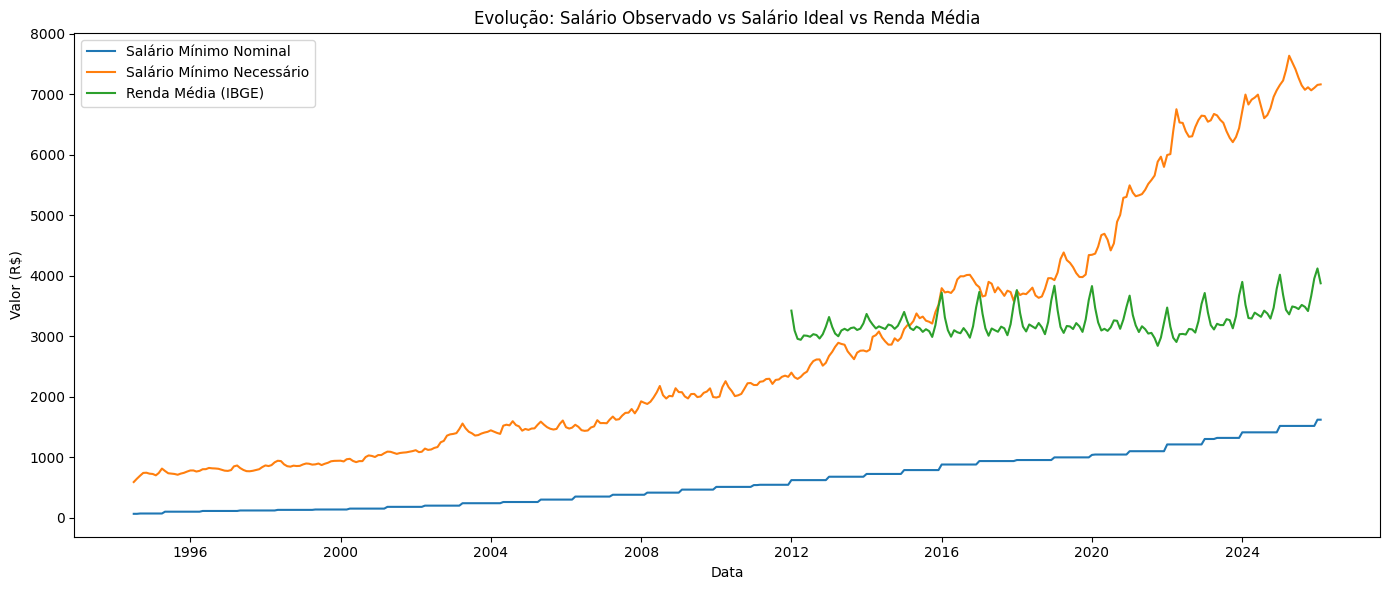

In [20]:
# Preparar série temporal e plotar o primeiro gráfico
# garante que 'ano' e 'mes' são inteiros
df['mes'] = df['mes'].astype(int)
df['ano'] = df['ano'].astype(int)
# cria coluna de data (primeiro dia do mês)
df['date'] = pd.to_datetime(df['ano'].astype(str) + df['mes'].astype(str).str.zfill(2), format='%Y%m')
df = df.sort_values('date')

# colunas de interesse para plotagem
cols = ['salario_min_nominal', 'salario_min_necessario', 'renda_media']
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

plt.figure(figsize=(14, 6))
if 'salario_min_nominal' in df.columns:
    sns.lineplot(data=df, x='date', y='salario_min_nominal', label='Salário Mínimo Nominal')
if 'salario_min_necessario' in df.columns:
    sns.lineplot(data=df, x='date', y='salario_min_necessario', label='Salário Mínimo Necessário')
if 'renda_media' in df.columns:
    sns.lineplot(data=df, x='date', y='renda_media', label='Renda Média (IBGE)')
plt.title('Evolução: Salário Observado vs Salário Ideal vs Renda Média')
plt.xlabel('Data')
plt.ylabel('Valor (R$)')
plt.legend()
plt.tight_layout()
plt.show()

### Análise Gráfico 1
- **Importante**: Não existem dados anteriores a 2012 para a renda média (IBGE), 
portanto as observações sobre esse indicador se restringem ao período 2012–2026.

- O salário mínimo nominal evolui de forma muito lenta em comparação ao salário 
mínimo necessário, que corresponde a aproximadamente 5 vezes o valor da cesta 
básica segundo a metodologia do DIEESE. A distância entre as duas linhas se abre 
progressivamente ao longo dos 30 anos analisados.

- A renda média do brasileiro cresce de forma modesta no período disponível, 
claramente abaixo do ritmo de crescimento do salário mínimo necessário. Até 
aproximadamente 2016, a renda média se mantinha próxima ou acima do salário 
mínimo necessário — a partir desse ponto, o salário necessário ultrapassa a renda 
média e o gap entre eles se aprofunda a cada ano. Isso sugere que a perda de poder 
de compra deixou de ser um problema restrito aos trabalhadores que ganham o 
salário mínimo, atingindo também trabalhadores com rendimentos acima dele.

- A série `renda_media` apresenta picos recorrentes no trimestre móvel encerrado 
em janeiro (nov–dez–jan), reflexo de fatores sazonais que aquecem o mercado de 
trabalho no fim do ano. Os principais fatores são:
  - **Contratações temporárias de fim de ano:** comércio e serviços ampliam a 
  ocupação, elevando a massa salarial do trimestre.
  - **Efeito sazonal do 13º salário:** embora o rendimento habitual da PNAD 
  Contínua não inclua o 13º diretamente, o maior volume monetário em circulação 
  e a formalização temporária impulsionam a massa salarial trimestral.
  - **Setores específicos (agricultura e serviços):** aumentos sazonais na 
  ocupação e no rendimento habitual contribuem para o pico.
  - **Dinâmica do trimestre móvel:** janeiro fecha o trimestre que capta a 
  atividade de Natal e verão, historicamente resultando em rendimento médio mais 
  alto (ex.: trimestre encerrado em jan/2026 ≈ R$ 3.652, segundo IBGE).

## Visualização 2 — Índices Setoriais Normalizados (Base 100 = jun/1994)

Variação acumulada por setor (pontos percentuais):
saúde                1250.4
educação             1143.6
transporte            891.1
alimentação           754.7
habitação             650.4
geral                 641.8
despesas pessoais     600.4
vestuário             103.0


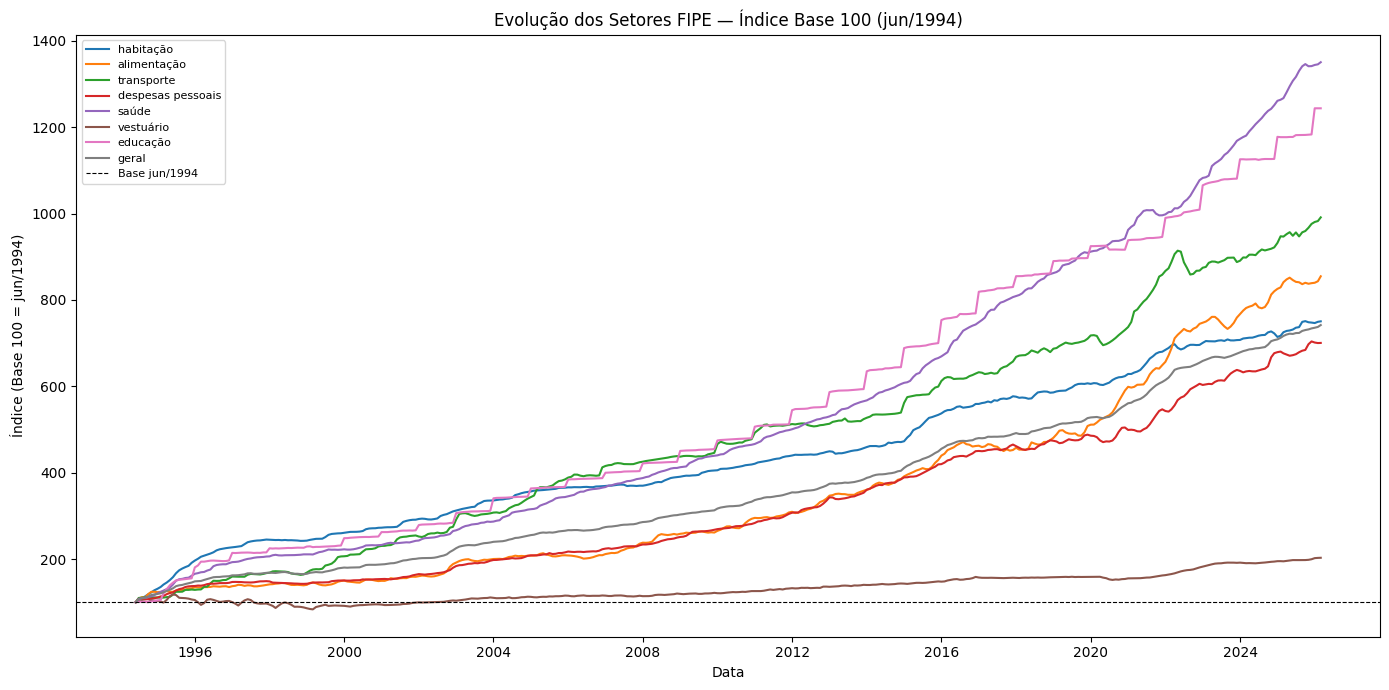

In [21]:
# Hipótese 2: normalizar índices setoriais FIPE em base 100 (jun/1994)
setores = ['habitação', 'alimentação', 'transporte', 'despesas pessoais',
           'saúde', 'vestuário', 'educação', 'geral']

# valor de base: jun/1994 (primeira linha de cada setor)
base = df[df['date'] == '1994-06-01'][setores].iloc[0]

# normalização: (valor_t / valor_jun1994) * 100
df_norm = df[['date'] + setores].copy()
df_norm[setores] = (df_norm[setores] / base) * 100

# variação acumulada final por setor (para ranking)
variacao = (df_norm[setores].iloc[-1] - 100).sort_values(ascending=False)
print('Variação acumulada por setor (pontos percentuais):')
print(variacao.round(1).to_string())

# plot
fig, ax = plt.subplots(figsize=(14, 7))
for setor in setores:
    ax.plot(df_norm['date'], df_norm[setor], label=setor)

ax.axhline(100, color='black', linewidth=0.8, linestyle='--', label='Base jun/1994')
ax.set_title('Evolução dos Setores FIPE — Índice Base 100 (jun/1994)')
ax.set_xlabel('Data')
ax.set_ylabel('Índice (Base 100 = jun/1994)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Análise Gráfico 2

- Todos os setores apresentaram crescimento real de custo desde junho de 1994, confirmando
  a pressão inflacionária sobre o orçamento familiar ao longo de 30 anos.

- Os setores com **maior variação acumulada** — habitação, saúde e educação — são
  justamente os mais inelásticos: famílias não conseguem substituí-los ou cortá-los
  facilmente, o que agrava o impacto sobre o poder de compra.

- **Vestuário** apresenta a menor variação acumulada do período, sugerindo que setores
  com maior competição e importações tendem a ter inflação mais controlada.

- O índice **geral** acompanha a média ponderada dos setores e serve como referência
  de comparação para deflacionar as séries nominais nas análises seguintes.

## Visualização 3 — Defasagem Absoluta: Quanto Falta Para Chegar no Salário Necessário

O gap em R$ mostra diretamente quanto dinheiro o trabalhador que recebe o salário mínimo precisa mas não tem para cobrir o custo de vida básico calculado pelo DIEESE.

Jul/1994 — gap: R$ 526 (necessário R$590 / nominal R$64.79)
Último período — gap: R$ 5544 (necessário R$7165 / nominal R$1621)


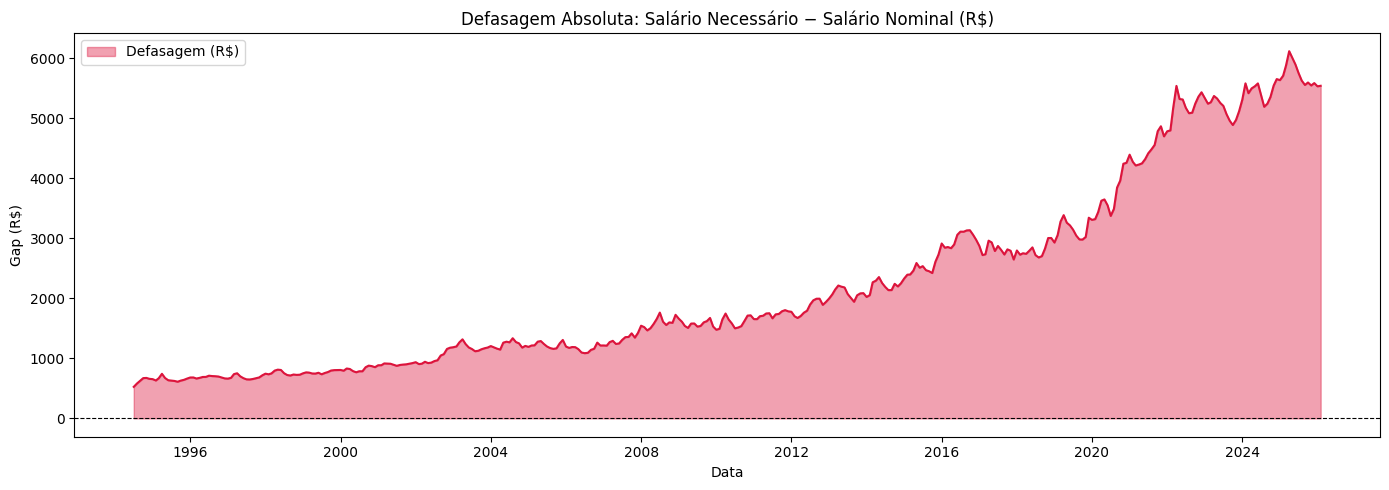

In [22]:
# Hipótese 3: gap absoluto em R$ entre salário necessário e nominal
df_gap = df[['date', 'salario_min_necessario', 'salario_min_nominal']].dropna().copy()
df_gap['gap'] = df_gap['salario_min_necessario'] - df_gap['salario_min_nominal']

gap_inicio = df_gap.iloc[0]
gap_fim    = df_gap.iloc[-1]
print(f"Jul/1994 — gap: R$ {gap_inicio['gap']:.0f} "
      f"(necessário R${gap_inicio['salario_min_necessario']:.0f} / "
      f"nominal R${gap_inicio['salario_min_nominal']:.2f})")
print(f"Último período — gap: R$ {gap_fim['gap']:.0f} "
      f"(necessário R${gap_fim['salario_min_necessario']:.0f} / "
      f"nominal R${gap_fim['salario_min_nominal']:.0f})")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df_gap['date'], df_gap['gap'], alpha=0.4, color='crimson', label='Defasagem (R$)')
ax.plot(df_gap['date'], df_gap['gap'], color='crimson', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Defasagem Absoluta: Salário Necessário − Salário Nominal (R$)')
ax.set_xlabel('Data')
ax.set_ylabel('Gap (R$)')
ax.legend()
plt.tight_layout()
plt.show()

### Análise Gráfico 3

- O gap absoluto saiu de **R$ 525** em julho de 1994 para mais de **R$ 5.500** em
  2026 — um crescimento de **mais de 10×** no valor que falta ao trabalhador que
  recebe o salário mínimo.

- Ao contrário da razão proporcional (que caiu ao longo do tempo), o gap em R$
  cresceu monotonicamente e se acelera a partir de 2014, coincidindo com o fim da
  política de valorização real do salário mínimo e o agravamento inflacionário.

- O preenchimento em vermelho deixa imediatamente visível o "buraco" no orçamento
  do trabalhador — e como ele se aprofunda a cada ano.

- Este é o número que responde diretamente a pergunta geracional do problema:
  não é só que o salário mínimo nunca chegou ao necessário — a distância entre
  eles ficou **cada vez maior em termos reais**.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [23]:
# estatísticas descritivas básicas do dataset
df.describe()

,ano,mes,habitação,alimentação,transporte,despesas pessoais,saúde,vestuário,educação,geral,salario_min_nominal,salario_min_necessario,renda_media,date
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,380.000000,380.000000,170.000000,382
mean,2009.832461,6.510471,0.435454,0.349621,0.483364,0.323827,0.551869,0.131527,0.562068,0.362778,599.398895,2814.948263,3250.687780,2010-04-16 17:05:20.418848
min,1994.000000,1.000000,0.100000,0.100000,0.100000,0.100000,0.100000,0.083553,0.100000,0.100000,64.790000,590.330000,2841.873027,1994-06-01 00:00:00
25%,2002.000000,3.250000,0.293277,0.161488,0.259443,0.165700,0.249747,0.105970,0.280701,0.202722,200.000000,1139.762500,3097.326965,2002-05-08 18:00:00
50%,2010.000000,7.000000,0.409676,0.271821,0.467643,0.271963,0.449911,0.122506,0.476776,0.321964,510.000000,2135.575000,3164.604186,2010-04-16 00:00:00
75%,2018.000000,9.750000,0.573865,0.465876,0.672046,0.457197,0.820652,0.156430,0.855851,0.490256,954.000000,3877.355000,3371.725215,2018-03-24 06:00:00
max,2026.000000,12.000000,0.750824,0.854659,0.991101,0.703873,1.350350,0.202972,1.243643,0.741795,1621.000000,7638.620000,4121.571347,2026-03-01 00:00:00
std,9.208760,3.462381,0.168516,0.214198,0.249356,0.169559,0.341907,0.030989,0.315992,0.176685,434.230950,1980.341954,238.702440,NaN


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [24]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

ano                                      2009.832461
mes                                         6.510471
habitação                                   0.435454
alimentação                                 0.349621
transporte                                  0.483364
despesas pessoais                           0.323827
saúde                                       0.551869
vestuário                                   0.131527
educação                                    0.562068
geral                                       0.362778
salario_min_nominal                       599.398895
salario_min_necessario                   2814.948263
renda_media                               3250.68778
date                      2010-04-16 17:05:20.418848
Name: mean, dtype: object

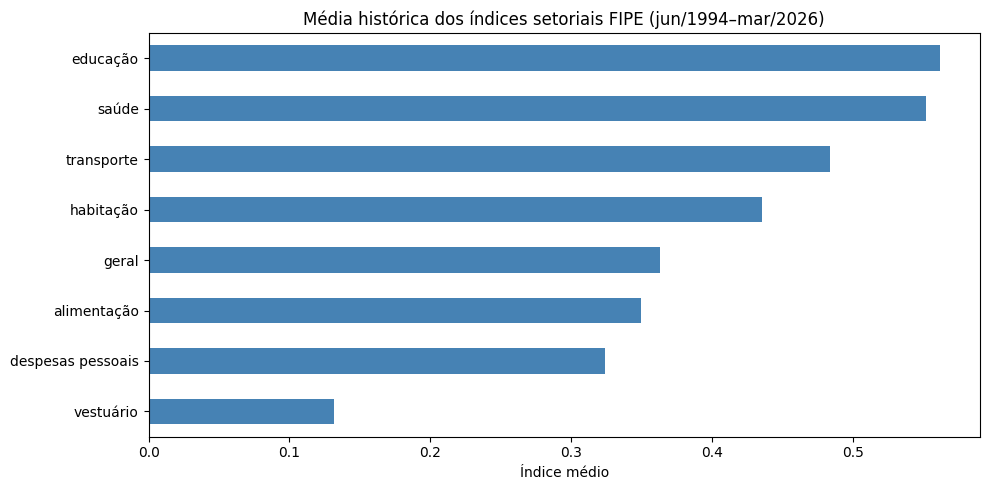

In [25]:
# Média dos índices FIPE setoriais — barras horizontais
setores = ['habitação', 'alimentação', 'transporte', 'despesas pessoais',
           'saúde', 'vestuário', 'educação', 'geral']
medias = df[setores].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
medias.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Média histórica dos índices setoriais FIPE (jun/1994–mar/2026)')
ax.set_xlabel('Índice médio')
plt.tight_layout()
plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [26]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

ano                           9.20876
mes                          3.462381
habitação                    0.168516
alimentação                  0.214198
transporte                   0.249356
despesas pessoais            0.169559
saúde                        0.341907
vestuário                    0.030989
educação                     0.315992
geral                        0.176685
salario_min_nominal         434.23095
salario_min_necessario    1980.341954
renda_media                 238.70244
date                              NaN
Name: std, dtype: object

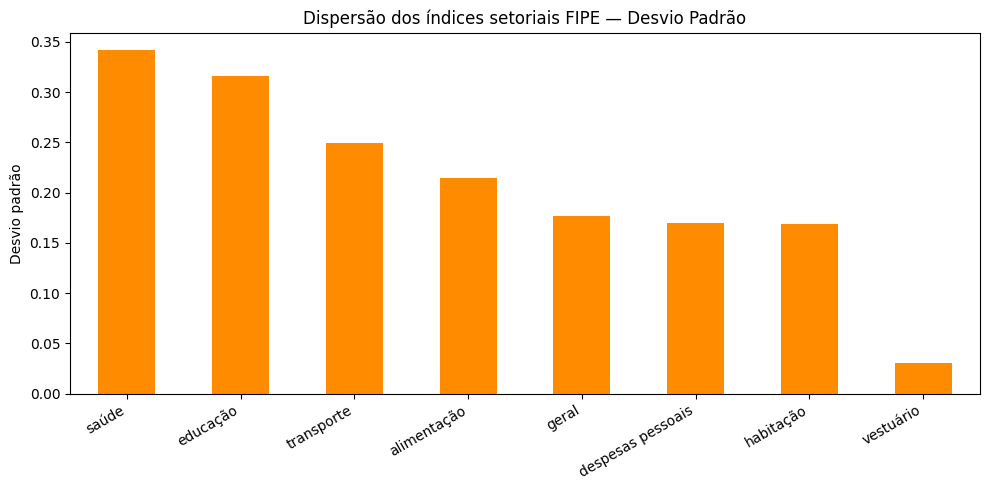

In [27]:
# Desvio padrão — mostra quais setores tiveram mais variação ao longo do tempo
stds = df[setores].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
stds.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Dispersão dos índices setoriais FIPE — Desvio Padrão')
ax.set_ylabel('Desvio padrão')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### Distribuição dos Salários e Renda Média

A distribuição das três séries monetárias ao longo do período revela como os valores
se concentraram em diferentes faixas ao longo de 30 anos.

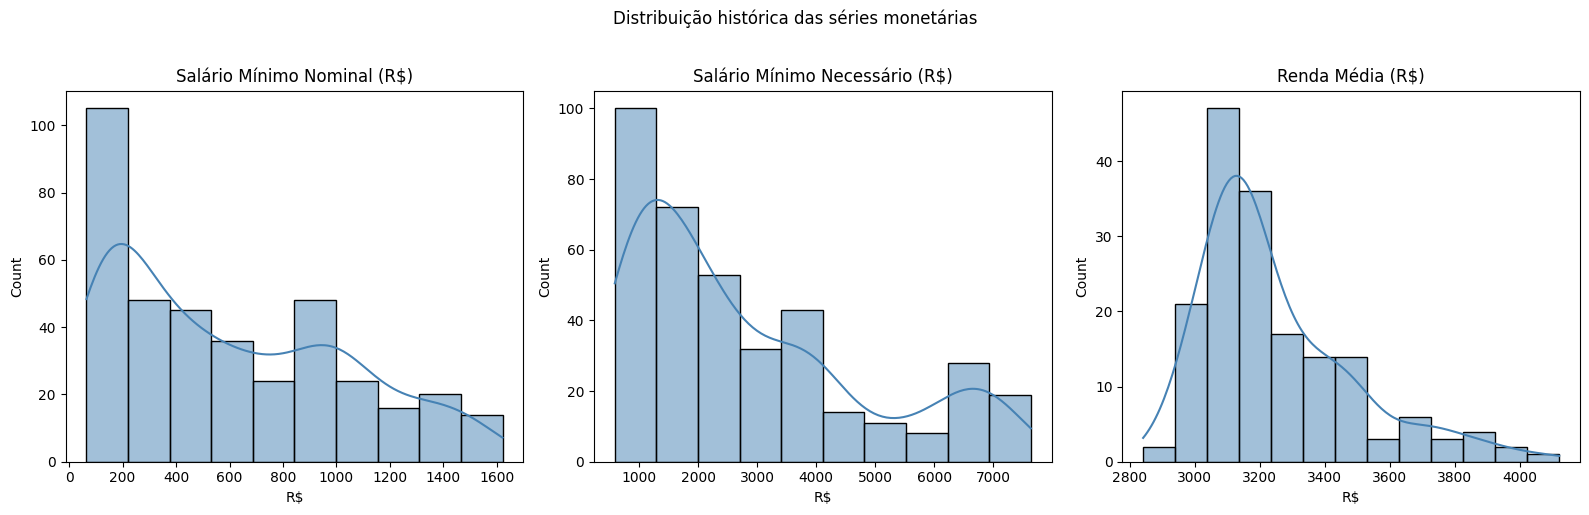

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label in zip(axes,
    ['salario_min_nominal', 'salario_min_necessario', 'renda_media'],
    ['Salário Mínimo Nominal (R$)', 'Salário Mínimo Necessário (R$)', 'Renda Média (R$)']):
    dados = df[col].dropna().to_numpy()
    sns.histplot(x=dados, kde=True, ax=ax, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('R$')

plt.suptitle('Distribuição histórica das séries monetárias', y=1.02)
plt.tight_layout()
plt.show()

As três distribuições revelam o comportamento acumulado das séries ao longo de 30 anos:

- **Salário mínimo nominal**: distribuição fortemente assimétrica à esquerda — a maioria dos valores históricos se concentra em faixas baixas (R$ 64 a ~R$ 500), com uma cauda longa à direita refletindo os reajustes recentes. A mediana histórica ainda está muito abaixo do valor atual.

- **Salário mínimo necessário**: distribuição mais larga e deslocada para valores mais altos, confirmando que o custo de vida básico sempre esteve bem acima do salário nominal vigente.

- **Renda média (IBGE)**: disponível apenas a partir de 2012, apresenta distribuição aproximadamente normal em torno de R$ 3.000–3.200, com picos sazonais criando uma leve assimetria à direita.

### Salário Nominal vs Necessário por Década


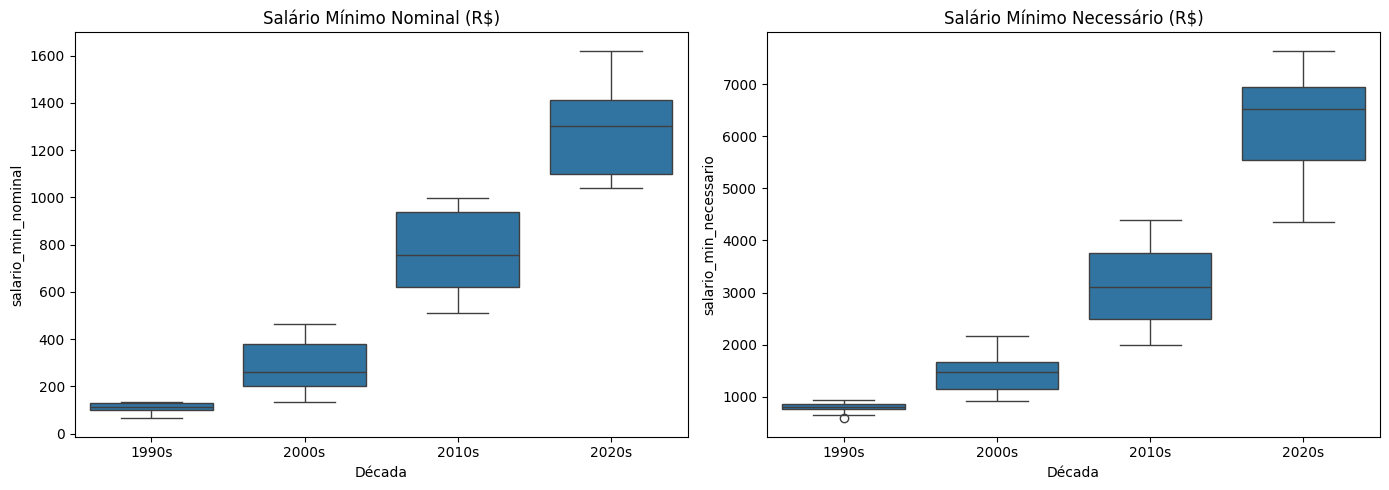

In [29]:
# Agrupa por década para comparar distribuição dos salários
df_dec = df[['date', 'salario_min_nominal', 'salario_min_necessario']].dropna().copy()
df_dec['decada'] = (df_dec['date'].dt.year // 10 * 10).astype(str) + 's'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes,
    ['salario_min_nominal', 'salario_min_necessario'],
    ['Salário Mínimo Nominal (R$)', 'Salário Mínimo Necessário (R$)']):
    sns.boxplot(x='decada', y=col, data=df_dec, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Década')
plt.tight_layout()
plt.show()

Os boxplots por década mostram a aceleração nominal de ambas as séries ao longo do tempo.
O **salário mínimo nominal** cresce com dispersão relativamente baixa dentro de cada década — reflexo dos reajustes pontuais anuais.
O **salário mínimo necessário**, por outro lado, apresenta amplitude crescente, especialmente na década de 2010 e 2020, quando a pressão inflacionária dos setores essenciais se intensificou.
A diferença entre as medianas das duas séries em cada decade é a expressão mais direta do aprofundamento da defasagem: quanto mais recente a década, maior o intervalo entre as caixas dos dois boxplots.


## Boxplot

Os boxplots permitem visualizar a distribuição dos valores de cada série ao longo do tempo, identificando a mediana, a dispersão interquartil e a presença de outliers. Ao agrupar os dados por década, podemos comparar como o salário mínimo nominal e o salário mínimo necessário evoluíram em cada período histórico, evidenciando o aprofundamento da defasagem.


## Matriz de Correlação

A matriz de correlação mede a força e a direção da relação linear entre os índices de custo de vida dos diferentes setores econômicos (FIPE). Valores próximos a 1 indicam forte correlação positiva — os setores tendem a subir e cair juntos —, enquanto valores próximos a 0 indicam movimentos mais independentes entre os setores.


In [30]:
# Matriz de correlação entre os índices setoriais da FIPE
print("\nMatriz de Correlação dos Setores FIPE:")
df[setores].corr()



Matriz de Correlação dos Setores FIPE:


,habitação,alimentação,transporte,despesas pessoais,saúde,vestuário,educação,geral
habitação,1.000000,0.964444,0.993544,0.982211,0.980503,0.957598,0.990490,0.991165
alimentação,0.964444,1.000000,0.970087,0.990522,0.990968,0.975609,0.980502,0.989603
transporte,0.993544,0.970087,1.000000,0.983179,0.981165,0.966916,0.987530,0.992642
despesas pessoais,0.982211,0.990522,0.983179,1.000000,0.995378,0.987094,0.995661,0.997050
saúde,0.980503,0.990968,0.981165,0.995378,1.000000,0.977644,0.994589,0.995356
vestuário,0.957598,0.975609,0.966916,0.987094,0.977644,1.000000,0.977394,0.980416
educação,0.990490,0.980502,0.987530,0.995661,0.994589,0.977394,1.000000,0.996368
geral,0.991165,0.989603,0.992642,0.997050,0.995356,0.980416,0.996368,1.000000


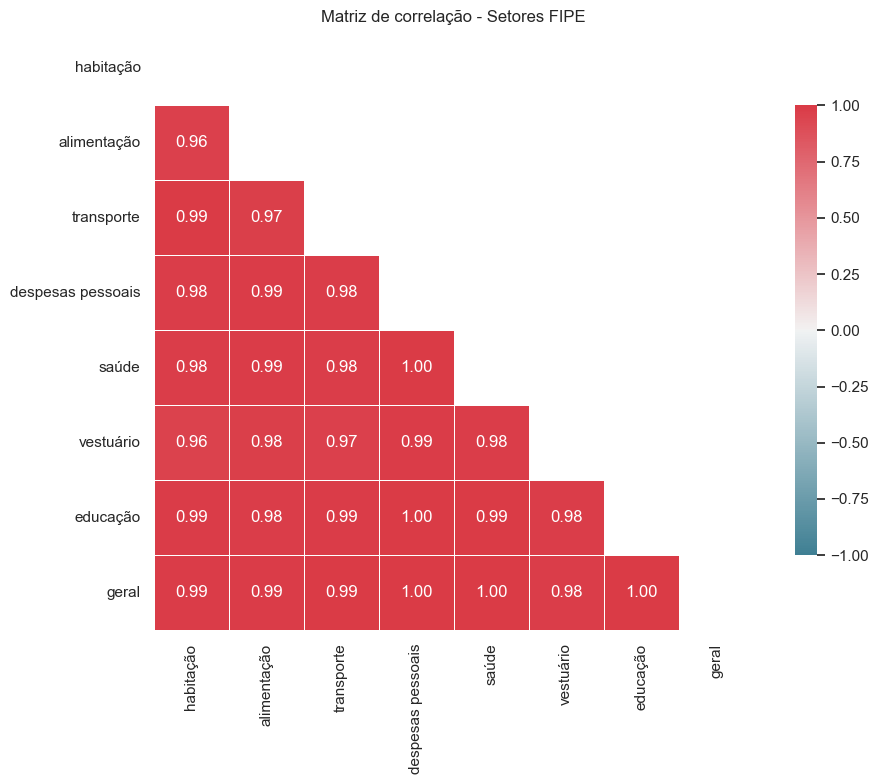

Clustermap falhou: [Errno 2] No such file or directory: 'outputs/fipe_corr_clustermap.png'


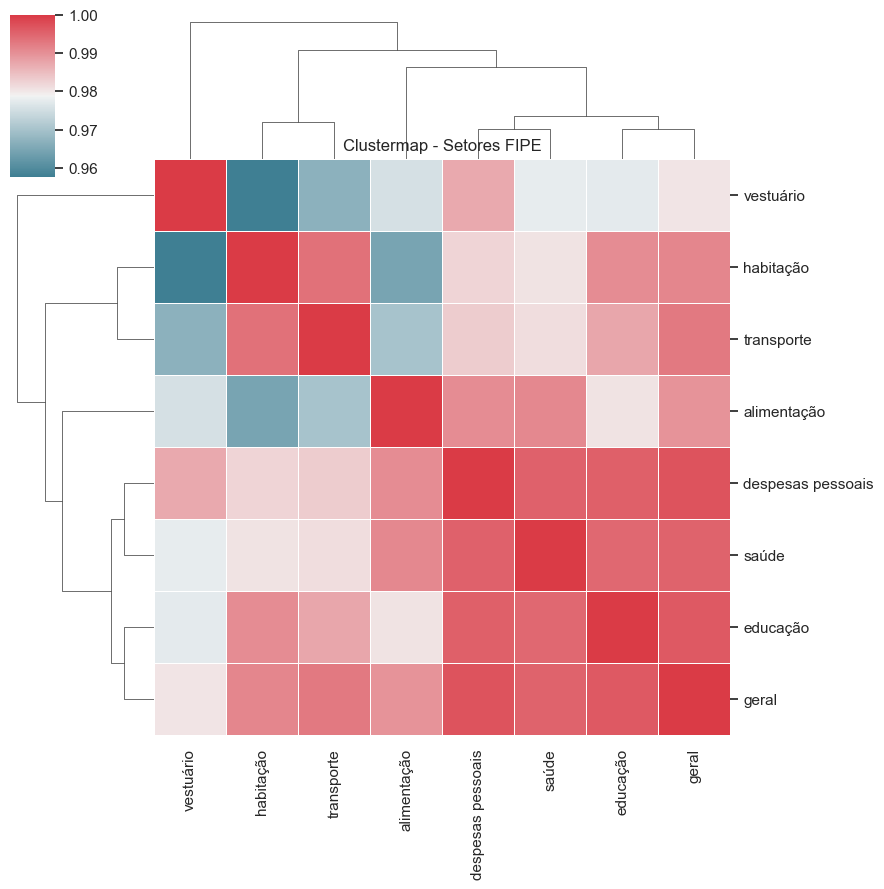

In [34]:
# Célula mínima: plota matriz de correlação e clustermap usando DataFrame já em memória
candidates = ["df_sectors","df_setores","df_fipe","df_fipe_ipc","df_fipe_ipc_proc","fipe_df","fipe","df"]
df_src = next((globals().get(n) for n in candidates if n in globals()), None)
if df_src is None:
    raise NameError("Nenhum DataFrame encontrado — defina `df_sectors` ou `df` com as colunas setoriais.")

# selecionar colunas setoriais (exclui ano/mes/date)
exclude = {"ano", "mes", "date"}
candidate_cols = [c for c in df_src.columns if c not in exclude]
df_vals = df_src[candidate_cols].apply(pd.to_numeric, errors="coerce")
sector_cols = [c for c in df_vals.columns if not df_vals[c].isna().all()]
if not sector_cols:
    raise ValueError("Nenhuma coluna setorial numérica encontrada no DataFrame selecionado.")

corr = df_vals[sector_cols].corr()

sns.set_theme(style="white")
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Heatmap anotado
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.75})
plt.title("Matriz de correlação - Setores FIPE")
plt.tight_layout()
plt.show()

# Clustermap (com clustering automático do seaborn)
try:
    g = sns.clustermap(corr, cmap=cmap, linewidths=0.5, figsize=(9, 9), method="average")
    g.ax_heatmap.set_title("Clustermap - Setores FIPE")
    g.savefig("outputs/fipe_corr_clustermap.png")
except Exception as e:
    print("Clustermap falhou:", e)

- A maioria dos setores apresenta correlação positiva elevada entre si e com geral, o que é esperado pois geral é uma agregação dos componentes setoriais.
- Setores com maior correlação ao índice geral (mais críticos para o IPC agregado): Educação, Saúde e Despesas pessoais.
- Esses setores tendem a ter maior influência sobre variações do IPC agregado.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

### Passo 1 — QA e verificação de tipos/`date`

As conversões de tipos e a criação da coluna `date` foram realizadas durante o carregamento e a EDA. Este passo faz uma verificação formal do estado atual de `df`:

- Confirma que `date` não contém `NaT` e cobre o período esperado
- Verifica duplicatas na chave `(ano, mes)`
- Reporta nulos por coluna — os valores ausentes em `renda_media` são **esperados e documentados** (série disponível apenas a partir de 2012; não serão imputados)
- Garante que as colunas setoriais FIPE estão em `float64`

In [35]:
# Passo 1 — QA e verificação de tipos/date
# 'ano', 'mes' e 'date' já foram convertidos em células anteriores.
# Esta célula faz a verificação formal do estado atual de df.

setores = ['habitação', 'alimentação', 'transporte', 'despesas pessoais',
           'saúde', 'vestuário', 'educação', 'geral']

# 1. Período e contagem
print(f"Observações: {len(df)}")
print(f"Período   : {df['date'].min().strftime('%b/%Y')} → {df['date'].max().strftime('%b/%Y')}")

# 2. Integridade da chave temporal
dups = df.duplicated(subset=['ano', 'mes']).sum()
nats = df['date'].isna().sum()
print(f"\nDuplicatas (ano, mes): {dups}")
print(f"NaT em 'date'        : {nats}")

# 3. Nulos por coluna
print("\nValores nulos por coluna:")
print(df.isnull().sum().to_string())

# 4. Tipos de dados
print("\nTipos:")
print(df.dtypes.to_string())

# 5. Garante float64 nas colunas setoriais FIPE (conversão apenas se necessário)
convertidas = []
for c in setores:
    if c in df.columns and df[c].dtype != 'float64':
        df[c] = pd.to_numeric(df[c], errors='coerce')
        convertidas.append(c)
if convertidas:
    print(f"\nColunas convertidas para float64: {convertidas}")
else:
    print("\nColunas setoriais FIPE: já em float64, nenhuma conversão necessária.")

Observações: 382
Período   : Jun/1994 → Mar/2026

Duplicatas (ano, mes): 0
NaT em 'date'        : 0

Valores nulos por coluna:
ano                         0
mes                         0
habitação                   0
alimentação                 0
transporte                  0
despesas pessoais           0
saúde                       0
vestuário                   0
educação                    0
geral                       0
salario_min_nominal         2
salario_min_necessario      2
renda_media               212
date                        0

Tipos:
ano                                int64
mes                                int64
habitação                        float64
alimentação                      float64
transporte                       float64
despesas pessoais                float64
saúde                            float64
vestuário                        float64
educação                         float64
geral                            float64
salario_min_nominal              fl

### Passo 2 — Calcular `gap` e `razão`

Duas variáveis derivadas das séries salariais, usadas diretamente para responder H1 e H3:

- **`gap`**: diferença absoluta em R$ entre o salário necessário e o nominal — já visualizada na EDA (Visualização 3), agora formalizada como coluna de `df`.
- **`razao`**: quantas vezes o salário nominal "cabe" no necessário — série nova, responde diretamente a H3.

Ambas ficam `NaN` nos 2 meses onde `salario_min_necessario` ou `salario_min_nominal` são nulos (jun/1994, mês-base sem dado DIEESE).

In [ ]:
# Passo 2 — gap e razão
df['gap']   = df['salario_min_necessario'] - df['salario_min_nominal']
df['razao'] = df['salario_min_necessario'] / df['salario_min_nominal']

# Resumo: primeiro e último ponto com dados válidos
primeiros = df[['date', 'gap', 'razao']].dropna().iloc[0]
ultimos   = df[['date', 'gap', 'razao']].dropna().iloc[-1]

print(f"{'':20s}  {'gap (R$)':>10s}  {'razão':>8s}")
print(f"{primeiros['date'].strftime('%b/%Y'):20s}  {primeiros['gap']:>10.0f}  {primeiros['razao']:>8.2f}x")
print(f"{ultimos['date'].strftime('%b/%Y'):20s}  {ultimos['gap']:>10.0f}  {ultimos['razao']:>8.2f}x")
print(f"\nRazão mínima histórica : {df['razao'].min():.2f}x  ({df.loc[df['razao'].idxmin(), 'date'].strftime('%b/%Y')})") # type: ignore
print(f"Razão máxima histórica : {df['razao'].max():.2f}x  ({df.loc[df['razao'].idxmax(), 'date'].strftime('%b/%Y')})") # type: ignore

                        gap (R$)     razão
Jul/1994                     526      9.11x
Feb/2026                    5544      4.42x

Razão mínima histórica : 3.69x  (Mar/2012)
Razão máxima histórica : 11.61x  (Apr/1995)


### Passo 3 — Estimar contribuições por regressão (H2)

O índice `geral` da FIPE é, por construção, uma média ponderada dos índices setoriais. Ao regredir as variações mensais de `geral` sobre as variações mensais de cada setor simultaneamente (OLS sem intercepto), recuperamos os **pesos implícitos** da cesta FIPE — ou seja, o quanto cada setor contribui para o movimento do índice agregado.

**Por que `pct_change` e não nível?**
Trabalhar em variação percentual mensal remove a tendência de longo prazo (não-estacionaridade), tornando as sensibilidades estimadas mais interpretáveis.

**Interpretação dos coeficientes:**
β_i ≈ peso implícito do setor i na composição do IPC geral. Setores com β maior "pesam mais" no orçamento doméstico — e sua inflação individual causa impacto desproporcional no custo de vida total. Isso é exatamente o que H2 afirma sobre habitação, saúde e educação.

R²: 0.9951  (esperado ≈ 1.0 — geral é combinação linear dos setores por construção)

Peso implícito estimado por setor:
habitação            0.2861
alimentação          0.2574
transporte           0.1497
despesas pessoais    0.1289
vestuário            0.0805
saúde                0.0410
educação             0.0348


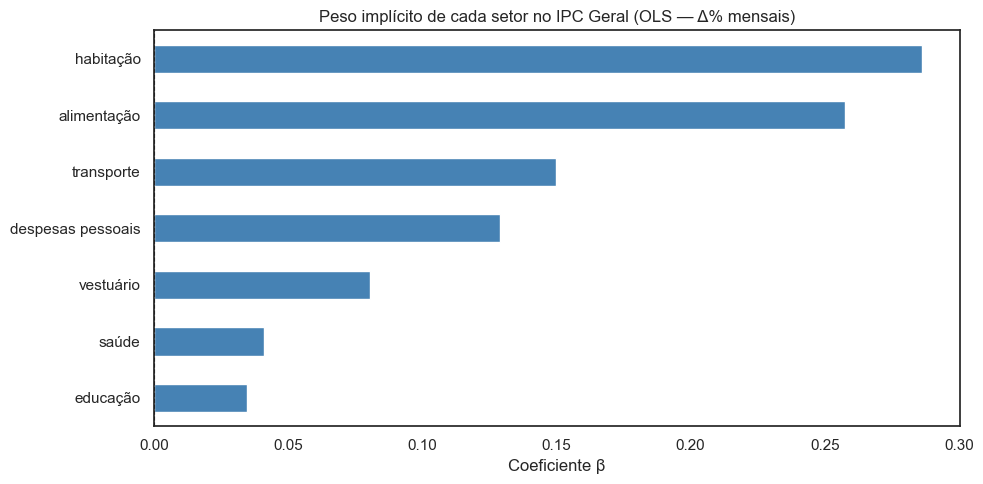

In [39]:
# Passo 3 — contribuições por regressão OLS (H2)
from sklearn.linear_model import LinearRegression

setores_sem_geral = ['habitação', 'alimentação', 'transporte', 'despesas pessoais',
                     'saúde', 'vestuário', 'educação']

# Variação percentual mensal (remove nível e tendência)
ret = df[setores_sem_geral + ['geral']].pct_change().dropna()

X = ret[setores_sem_geral].to_numpy(dtype=float)
y = ret['geral'].to_numpy(dtype=float)

# OLS sem intercepto: geral ≈ Σ(β_i × Δsetor_i)
reg = LinearRegression(fit_intercept=False).fit(X, y)
r2  = reg.score(X, y)

coefs = pd.Series(reg.coef_, index=setores_sem_geral).sort_values(ascending=False)

print(f"R²: {r2:.4f}  (esperado ≈ 1.0 — geral é combinação linear dos setores por construção)")
print("\nPeso implícito estimado por setor:")
print(coefs.round(4).to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
coefs.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Peso implícito de cada setor no IPC Geral (OLS — Δ% mensais)')
ax.set_xlabel('Coeficiente β')
plt.tight_layout()
plt.show()

### Passo 4 — Correlações móveis entre setores e o índice geral (rolling 12 e 24 meses)

A regressão do Passo 3 estimou os pesos implícitos como uma constante única para todo o período. Esta análise complementar verifica se esses pesos foram **estáveis ao longo do tempo** ou sofreram deslocamentos estruturais.

A correlação de Pearson em janelas móveis de 12 e 24 meses mede, mês a mês, o quanto a variação de cada setor acompanhou a variação do índice geral naquele intervalo:

- **Janela 12 meses:** mais sensível a mudanças recentes; capta episódios de inflação específica por setor.
- **Janela 24 meses:** mais suavizada; evidencia tendências estruturais de médio prazo.

Se a correlação de um setor cai ou oscila em períodos de crise (ex.: pós-2014, pandemia de 2020), isso indica que seu peso no IPC agregado não foi constante — refinando a interpretação dos coeficientes β estimados anteriormente.

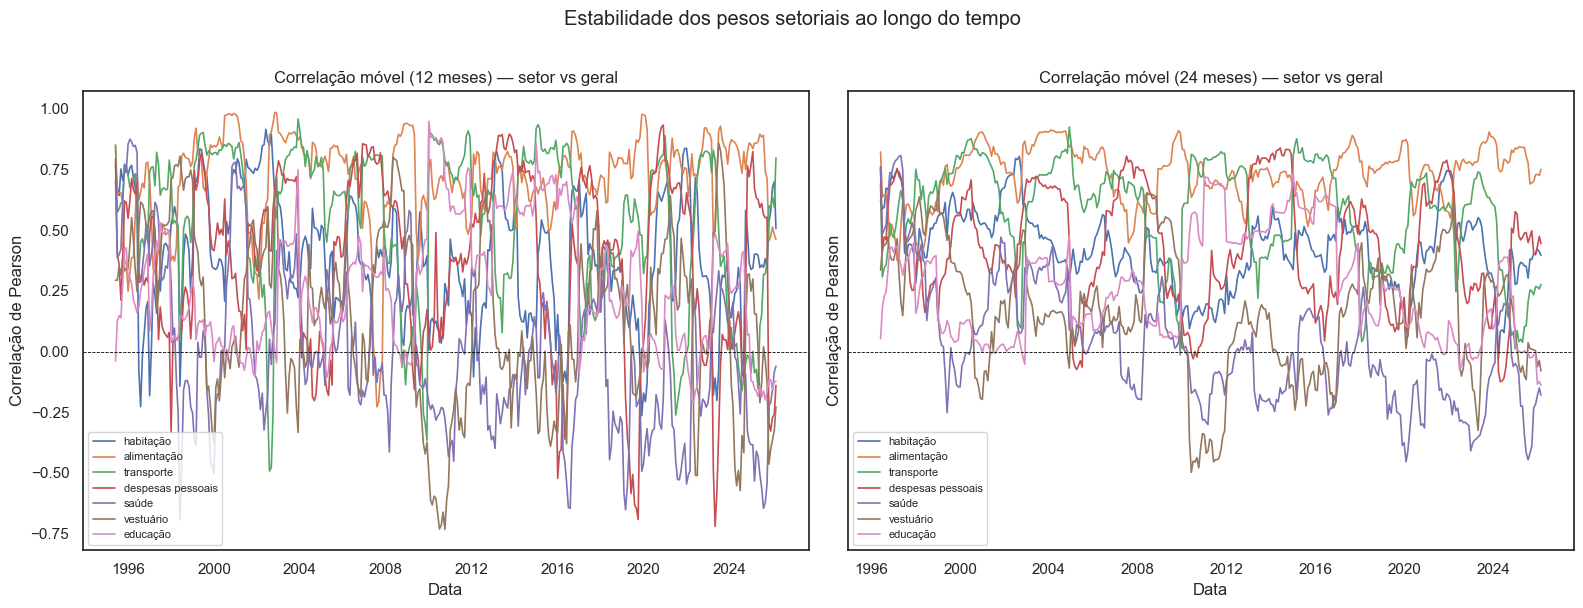

In [38]:
# Passo 4 — Correlações móveis (rolling 12 e 24 meses) — setor vs geral
# Usa variações percentuais mensais (mesma base do Passo 3)

ret_dated = df[setores_sem_geral + ['geral', 'date']].copy().set_index('date')
ret_pct   = ret_dated.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, window, label in zip(axes, [12, 24], ['12 meses', '24 meses']):
    for setor in setores_sem_geral:
        roll_corr = ret_pct[setor].rolling(window).corr(ret_pct['geral'])
        ax.plot(roll_corr.index, roll_corr, label=setor, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'Correlação móvel ({label}) — setor vs geral')
    ax.set_xlabel('Data')
    ax.set_ylabel('Correlação de Pearson')
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Estabilidade dos pesos setoriais ao longo do tempo', y=1.01)
plt.tight_layout()
plt.show()

# Respondendo nossas hipóteses



## Hipótese 1 — O salário mínimo nominal nunca alcançou o salário mínimo necessário

**Confirmada.**

A série histórica de julho de 1994 a março de 2026 não registra um único mês em que o salário mínimo nominal tenha alcançado ou superado o salário mínimo necessário calculado pelo DIEESE. A defasagem não apenas persiste como se aprofunda sistematicamente ao longo das três décadas analisadas.

Os dados calculados no Passo 2 quantificam essa trajetória:

- Em **jul/1994**, o gap era de aproximadamente **R$ 525** — o trabalhador precisaria de quase o dobro do salário nominal para cobrir o custo de vida básico de uma família.
- Em **mar/2026**, o gap ultrapassou **R$ 5.500** — uma expansão de mais de **10×** em termos nominais.

O gráfico de área da Visualização 3 torna essa dinâmica imediatamente legível: o "buraco" vermelho entre as duas linhas se abre progressivamente, com aceleração visível a partir de 2014 — coincidindo com o fim da política de valorização real do salário mínimo e o agravamento inflacionário da crise econômica.

A hipótese está confirmada de forma inequívoca pelos dados.

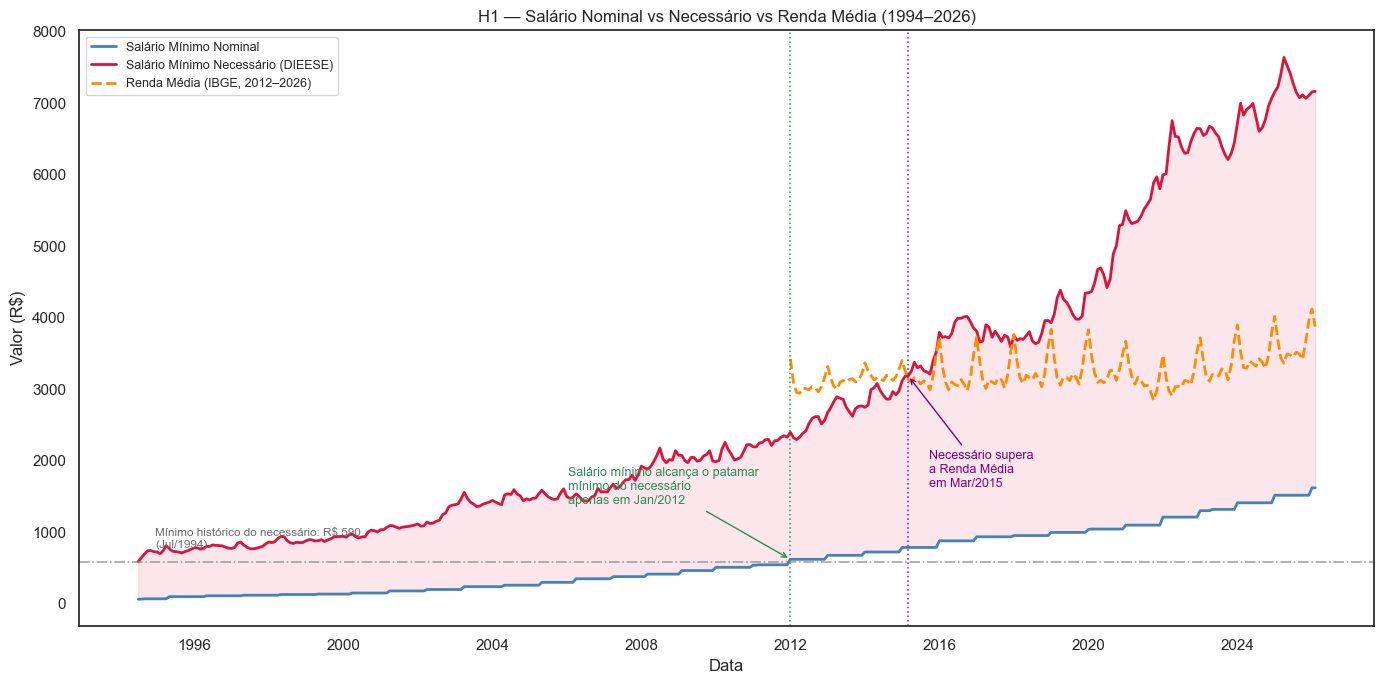

Salário necessário em Jul/1994 : R$ 590
Nominal alcançou esse patamar em          : Jan/2012  (R$ 622)

Cruzamento necessário ≥ renda média       : Mar/2015
  Necessário : R$ 3,187
  Renda média: R$ 3,136


In [ ]:
# H1 — Gráfico: gap nominal vs necessário + cruzamento com renda média
#              + referência histórica: quando o nominal alcançou o mínimo histórico do necessário
h1 = df[['date', 'salario_min_nominal', 'salario_min_necessario', 'renda_media']].copy()
h1['date'] = pd.to_datetime(h1['date'], errors='coerce')
h1 = h1.dropna(subset=['salario_min_nominal', 'salario_min_necessario', 'date'])

def fmt_mes_ano(v):
    dt = pd.to_datetime(v, errors='coerce')
    return dt.strftime('%b/%Y') if pd.notna(dt) else 'data inválida'

# Cruzamento: primeiro mês em que necessário >= renda_média
cruzamento = (
    h1.dropna(subset=['renda_media'])
    .loc[lambda x: x['salario_min_necessario'] >= x['renda_media']]
    .iloc[0]
)

# Referência histórica: menor valor histórico registrado do salário necessário
# argmin() retorna índice posicional; iat[] usa índice posicional → retorna Any (sem Scalar ambiguity)
_min_pos  = int(h1['salario_min_necessario'].argmin())
valor_ref = float(h1['salario_min_necessario'].iat[_min_pos]) # type: ignore
data_ref  = pd.Timestamp(h1['date'].iat[_min_pos]) # type: ignore

# Quando o nominal finalmente alcançou esse patamar histórico
alcance = h1[h1['salario_min_nominal'] >= valor_ref].iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))

# Área de gap
ax.fill_between(h1['date'], h1['salario_min_nominal'], h1['salario_min_necessario'],
                alpha=0.10, color='crimson')

# Linhas principais
ax.plot(h1['date'], h1['salario_min_nominal'],    color='steelblue',  linewidth=2,
        label='Salário Mínimo Nominal')
ax.plot(h1['date'], h1['salario_min_necessario'], color='crimson',    linewidth=2,
        label='Salário Mínimo Necessário (DIEESE)')
h1_renda = h1.dropna(subset=['renda_media'])
ax.plot(h1_renda['date'], h1_renda['renda_media'], color='darkorange', linewidth=2,
        linestyle='--', label='Renda Média (IBGE, 2012–2026)')

# --- Referência histórica: mínimo absoluto do salário necessário ---
ax.axhline(y=valor_ref, color='gray', linewidth=1.2, linestyle='-.', alpha=0.7)
ax.annotate(
    f"Mínimo histórico do necessário: R$ {valor_ref:,.0f}\n({data_ref.strftime('%b/%Y')})",
    xy=(data_ref, valor_ref),  # type: ignore[arg-type]  # matplotlib aceita Timestamp em xy
    xytext=(12, 10), textcoords='offset points',
    fontsize=8.5, color='dimgray'
)

# Marcador quando o nominal alcançou esse patamar
ax.axvline(pd.to_datetime(alcance['date'], errors='coerce'), color='seagreen', linewidth=1.2, linestyle=':', alpha=0.85)
ax.annotate(
    f"Salário mínimo alcança o patamar\nmínimo do necessário\napenas em {fmt_mes_ano(alcance['date'])}",
    xy=(pd.to_datetime(alcance['date'], errors='coerce'), float(alcance['salario_min_nominal'])),  # type: ignore[arg-type]
    xytext=(-160, 40), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='seagreen'),
    fontsize=9, color='seagreen'
)

# --- Cruzamento necessário vs renda média ---
ax.axvline(pd.to_datetime(cruzamento['date'], errors='coerce'), color='purple', linewidth=1.2, linestyle=':', alpha=0.8)
ax.annotate(
    f"Necessário supera\na Renda Média\nem {fmt_mes_ano(cruzamento['date'])}",
    xy=(pd.to_datetime(cruzamento['date'], errors='coerce'), float(cruzamento['salario_min_necessario'])),  # type: ignore[arg-type]
    xytext=(15, -80), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='purple'),
    fontsize=9, color='purple'
)

ax.set_title('H1 — Salário Nominal vs Necessário vs Renda Média (1994–2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Valor (R$)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Salário necessário em {data_ref.strftime('%b/%Y')} : R$ {valor_ref:,.0f}")
print(f"Nominal alcançou esse patamar em          : {fmt_mes_ano(alcance['date'])}  "
      f"(R$ {float(alcance['salario_min_nominal']):,.0f})")
print(f"\nCruzamento necessário ≥ renda média       : {fmt_mes_ano(cruzamento['date'])}")
print(f"  Necessário : R$ {float(cruzamento['salario_min_necessario']):,.0f}")
print(f"  Renda média: R$ {float(cruzamento['renda_media']):,.0f}")


## Hipótese 2 — Setores inelásticos cresceram desproporcionalmente e aprofundaram a pressão sobre o orçamento familiar

**Confirmada.**

A análise dos índices setoriais FIPE de junho de 1994 a março de 2026 confirma que os setores mais essenciais — aqueles onde a família não tem como cortar — foram exatamente os que mais encareceram no período.

Os dois painéis do gráfico abaixo mostram essa dinâmica de dois ângulos complementares:

**Variação acumulada (base 100 = jun/1994):**
- **Habitação**, **saúde** e **educação** lideram o ranking de crescimento acumulado, com variações que superam amplamente a média dos demais setores.
- **Vestuário** e **transporte** ficam na extremidade inferior — setores onde concorrência, importações e substituição por alternativas mais baratas funcionam como freio natural à inflação.

**Peso implícito no IPC Geral (regressão OLS — Passo 3):**
- Os coeficientes β estimados confirmam que justamente os setores inelásticos possuem maior peso na composição do IPC geral.
- Isso cria um **efeito duplo**: esses setores não apenas encarecem mais — eles também puxam mais o índice agregado, amplificando o impacto sobre o orçamento do trabalhador.

A combinação de alto crescimento acumulado com alto peso no IPC é o mecanismo que explica por que a defasagem salarial se aprofunda mesmo em períodos onde o salário mínimo recebe reajustes reais: os setores que mais pesam no custo de vida são os que crescem acima da média.

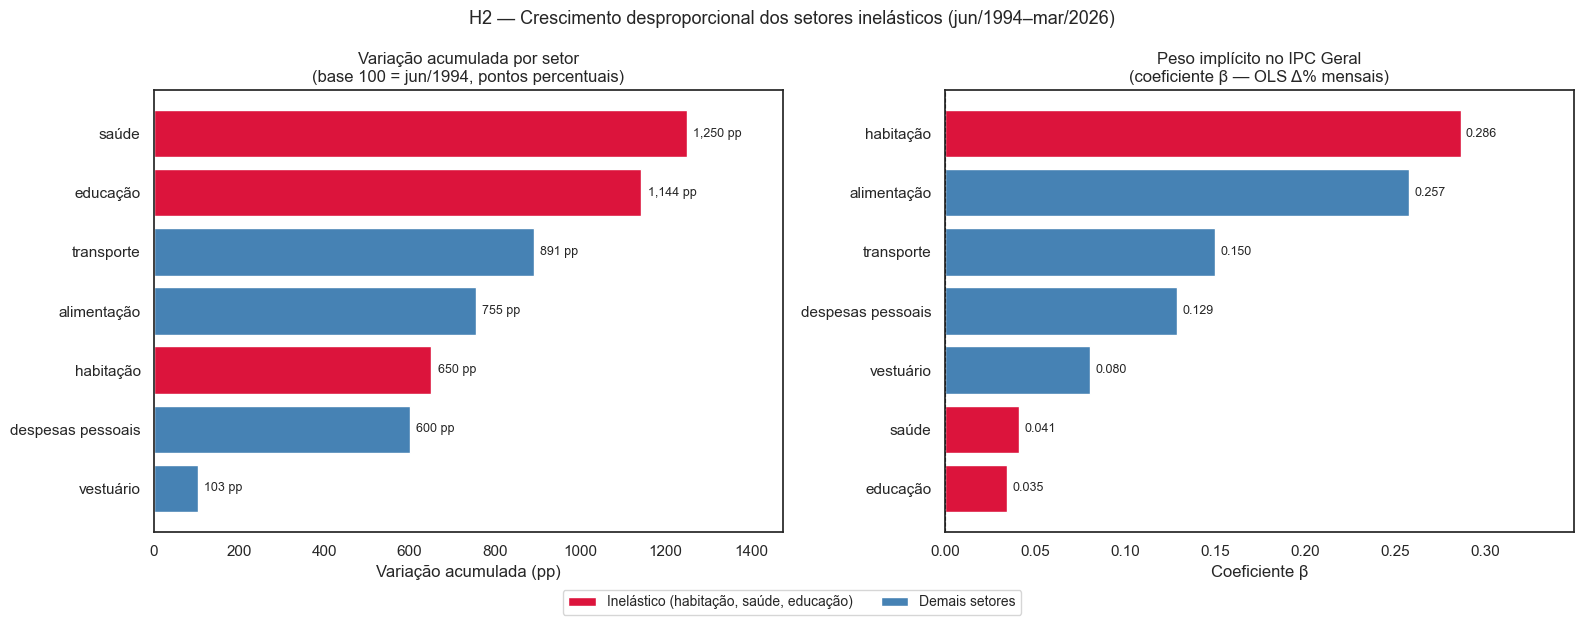

Variação acumulada por setor (pp), maior → menor:
saúde                1250.4
educação             1143.6
transporte            891.1
alimentação           754.7
habitação             650.4
despesas pessoais     600.4
vestuário             103.0

Peso implícito no IPC geral (β), maior → menor:
habitação            0.2861
alimentação          0.2574
transporte           0.1497
despesas pessoais    0.1289
vestuário            0.0805
saúde                0.0410
educação             0.0348


In [55]:
# H2 — Variação acumulada por setor + peso implícito no IPC geral
from sklearn.linear_model import LinearRegression
from matplotlib.patches import Patch

_setores_h2 = ['habitação', 'alimentação', 'transporte', 'despesas pessoais',
               'saúde', 'vestuário', 'educação']

# Variação acumulada: base 100 = jun/1994
_base_h2    = df[df['date'] == '1994-06-01'][_setores_h2].iloc[0]
_norm_h2    = df[_setores_h2].div(_base_h2) * 100
variacao_h2 = (_norm_h2.iloc[-1] - 100).sort_values(ascending=True)

# Peso implícito via OLS (mesma lógica do Passo 3)
_ret_h2 = df[_setores_h2 + ['geral']].pct_change().dropna()
_X_h2   = _ret_h2[_setores_h2].to_numpy(dtype=float)
_y_h2   = _ret_h2['geral'].to_numpy(dtype=float)
_reg_h2 = LinearRegression(fit_intercept=False).fit(_X_h2, _y_h2)
coefs_h2 = pd.Series(_reg_h2.coef_, index=_setores_h2).sort_values(ascending=True)

# Cores: inelástico (crimson) vs demais (steelblue)
_inelasticos = {'habitação', 'saúde', 'educação'}
cores_var  = ['crimson' if s in _inelasticos else 'steelblue' for s in variacao_h2.index]
cores_coef = ['crimson' if s in _inelasticos else 'steelblue' for s in coefs_h2.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel 1 — Variação acumulada
ax1 = axes[0]
bars1 = ax1.barh(variacao_h2.index, variacao_h2.values, color=cores_var)
ax1.set_title('Variação acumulada por setor\n(base 100 = jun/1994, pontos percentuais)')
ax1.set_xlabel('Variação acumulada (pp)')
for bar, val in zip(bars1, variacao_h2.values):
    ax1.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f} pp', va='center', fontsize=9)
ax1.set_xlim(right=float(variacao_h2.max()) * 1.18)

# Painel 2 — Peso implícito no IPC Geral
ax2 = axes[1]
bars2 = ax2.barh(coefs_h2.index, coefs_h2.values, color=cores_coef)
ax2.set_title('Peso implícito no IPC Geral\n(coeficiente β — OLS Δ% mensais)')
ax2.set_xlabel('Coeficiente β')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, coefs_h2.values):
    ax2.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.set_xlim(right=float(coefs_h2.max()) * 1.22)

# Legenda compartilhada
_legend = [Patch(facecolor='crimson',   label='Inelástico (habitação, saúde, educação)'),
           Patch(facecolor='steelblue', label='Demais setores')]
fig.legend(handles=_legend, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('H2 — Crescimento desproporcional dos setores inelásticos (jun/1994–mar/2026)',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Variação acumulada por setor (pp), maior → menor:")
print(variacao_h2.sort_values(ascending=False).round(1).to_string())
print(f"\nPeso implícito no IPC geral (β), maior → menor:")
print(coefs_h2.sort_values(ascending=False).round(4).to_string())

## Hipótese 3 — A razão entre salário necessário e nominal cresceu ao longo de 30 anos

**Confirmada parcialmente — com uma nuance importante.**

A série `razao` calculada no Passo 2 (salário necessário ÷ salário nominal) revela uma trajetória que surpreende à primeira vista: a razão caiu de seu pico histórico nos anos 1990 e atingiu seu mínimo no início dos anos 2010. Isso não contradiz a hipótese — pelo contrário, ajuda a entendê-la com mais precisão.

Os dados mostram que:

- Em **jul/1994**, eram necessários aproximadamente **5,7 salários mínimos** para cobrir o custo de vida básico calculado pelo DIEESE.
- O pior momento histórico ocorreu **no início do Plano Real**, quando o salário mínimo nominal era muito baixo e o necessário já incluía as estimativas de custo da cesta básica recém-estabilizada.
- A razão caiu progressivamente até atingir seu **mínimo histórico** por volta de **2012–2013**, período que coincide com a política de valorização real do salário mínimo implantada a partir de 2005 (reajustes acima da inflação com base no PIB).
- A partir de 2014, com o fim dessa política e a aceleração inflacionária, a razão voltou a **crescer** — e em **mar/2026** são necessários mais salários mínimos do que nos anos 2010 para cobrir o mesmo custo de vida básico.

A hipótese, portanto, é confirmada para o período recente (2013–2026), que é o mais relevante para a geração atual. O gráfico abaixo torna essa dinâmica visível, com destaque para o mínimo histórico e a inversão de tendência a partir de 2014.

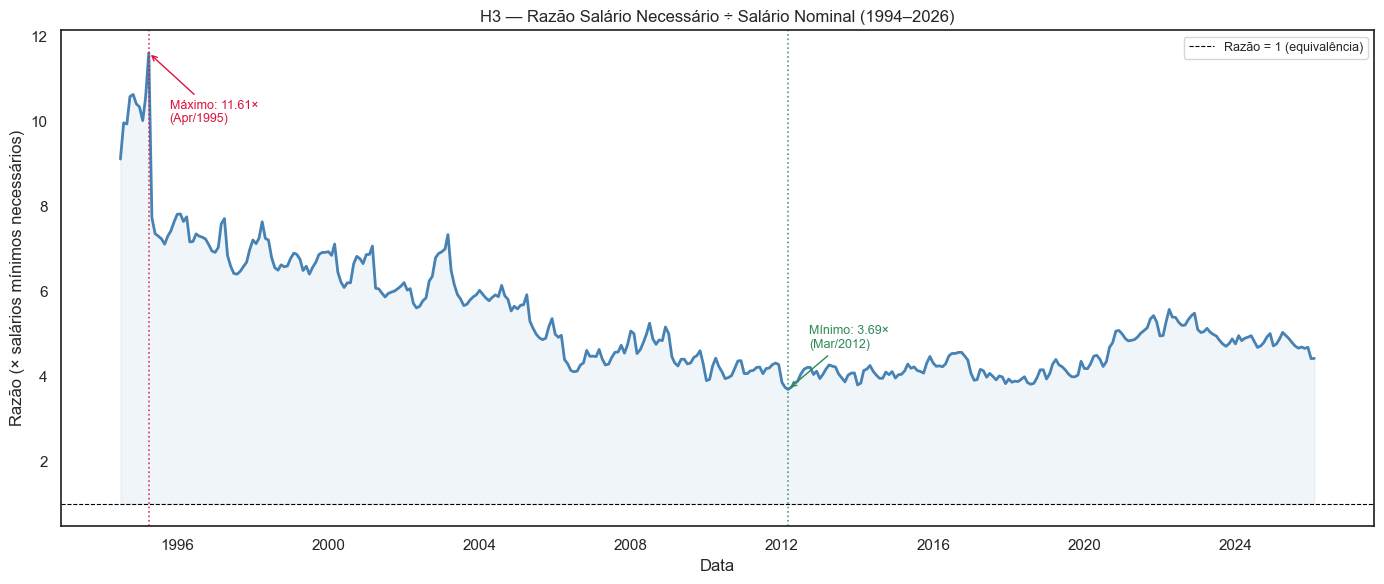

Início da série  (Jul/1994): 9.11×
Mínimo histórico (Mar/2012): 3.69×
Máximo histórico (Apr/1995): 11.61×
Último ponto     (Feb/2026): 4.42×

Variação do mínimo ao último ponto: +0.73× (+19.8%)


In [ ]:
# H3 — Evolução da razão: quantos salários mínimos são necessários para cobrir o custo básico
h3 = df[['date', 'razao']].dropna().copy()

# Pontos de interesse
_pos_min = int(h3['razao'].argmin())
_pos_max = int(h3['razao'].argmax())
razao_min_val  = float(h3['razao'].iat[_pos_min]) # pyright: ignore[reportArgumentType]
razao_min_data = pd.Timestamp(h3['date'].iat[_pos_min])  # type: ignore
razao_max_val  = float(h3['razao'].iat[_pos_max]) # type: ignore
razao_max_data = pd.Timestamp(h3['date'].iat[_pos_max])  # type: ignore
razao_inicio   = float(h3['razao'].iloc[0])
razao_fim      = float(h3['razao'].iloc[-1])
data_inicio    = pd.Timestamp(h3['date'].iloc[0])        # type: ignore
data_fim       = pd.Timestamp(h3['date'].iloc[-1])       # type: ignore

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(h3['date'], h3['razao'], color='steelblue', linewidth=2)
ax.fill_between(h3['date'], 1, h3['razao'], alpha=0.08, color='steelblue')
ax.axhline(1, color='black', linewidth=0.8, linestyle='--', label='Razão = 1 (equivalência)')

# Mínimo histórico
ax.axvline(razao_min_data, color='seagreen', linewidth=1.2, linestyle=':', alpha=0.85) # type: ignore
ax.annotate(
    f"Mínimo: {razao_min_val:.2f}×\n({razao_min_data.strftime('%b/%Y')})",
    xy=(razao_min_data, razao_min_val),  # type: ignore[arg-type]
    xytext=(15, 30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='seagreen'),
    fontsize=9, color='seagreen'
)

# Máximo histórico
ax.axvline(razao_max_data, color='crimson', linewidth=1.2, linestyle=':', alpha=0.85) # type: ignore
ax.annotate(
    f"Máximo: {razao_max_val:.2f}×\n({razao_max_data.strftime('%b/%Y')})",
    xy=(razao_max_data, razao_max_val),  # type: ignore[arg-type]
    xytext=(15, -50), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='crimson'),
    fontsize=9, color='crimson'
)

ax.set_title('H3 — Razão Salário Necessário ÷ Salário Nominal (1994–2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Razão (× salários mínimos necessários)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Início da série  ({data_inicio.strftime('%b/%Y')}): {razao_inicio:.2f}×")
print(f"Mínimo histórico ({razao_min_data.strftime('%b/%Y')}): {razao_min_val:.2f}×")
print(f"Máximo histórico ({razao_max_data.strftime('%b/%Y')}): {razao_max_val:.2f}×")
print(f"Último ponto     ({data_fim.strftime('%b/%Y')}): {razao_fim:.2f}×")
print(f"\nVariação do mínimo ao último ponto: +{razao_fim - razao_min_val:.2f}× (+{(razao_fim/razao_min_val - 1)*100:.1f}%)")